# Deconvolve Chromatin - Refactor and Find Gamma


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_grid_compute import ChromatinGrid

chromatin_gridder = ChromatinGrid()

In [3]:
chromatin_gridder.set_gene('CLB2')

In [5]:
chromatin_gridder.create_bins_per_all_sample()

The histogram shape around the TSS is: (3, 9)


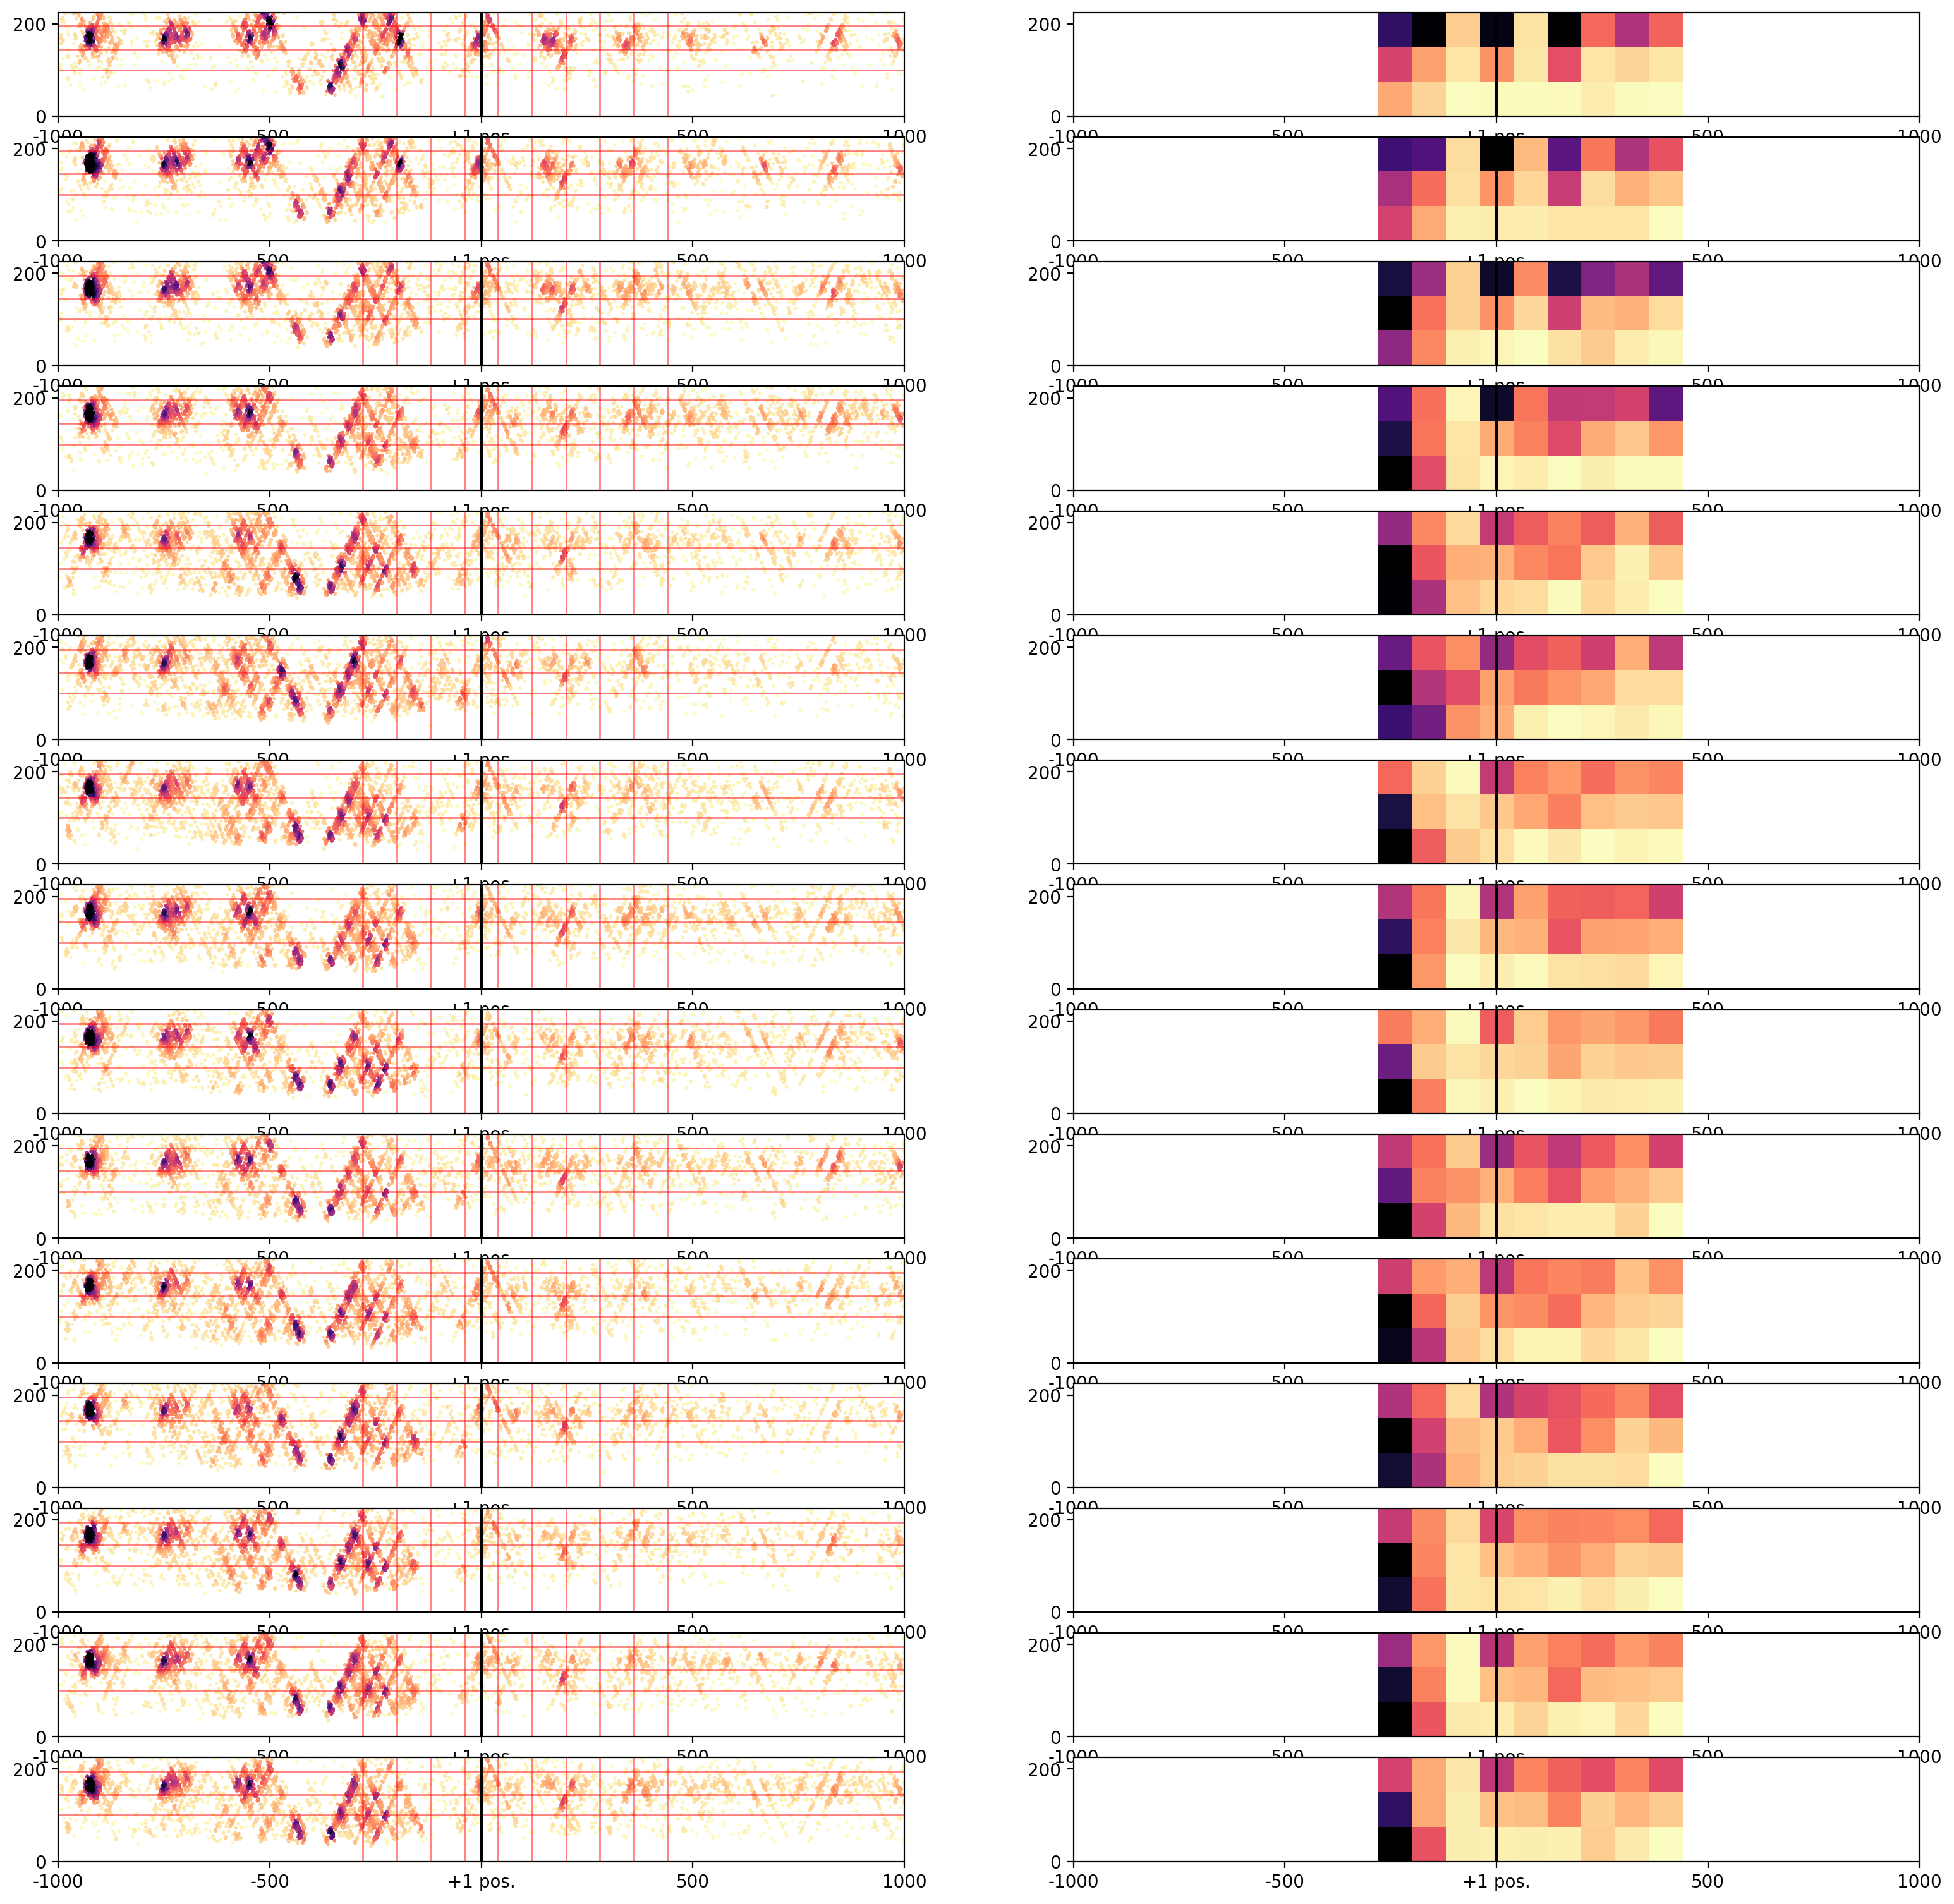

In [7]:
chromatin_gridder.plot_raw_and_grid()

The first histogram is shape: (3, 9)
Reshaping this histogram to a vector of shape: (27,)
Then, if we were to take that first vector and restore it to its original shape: (3, 9)
Now we have a data structure that we can try to deconvolve of shape: (15, 27)


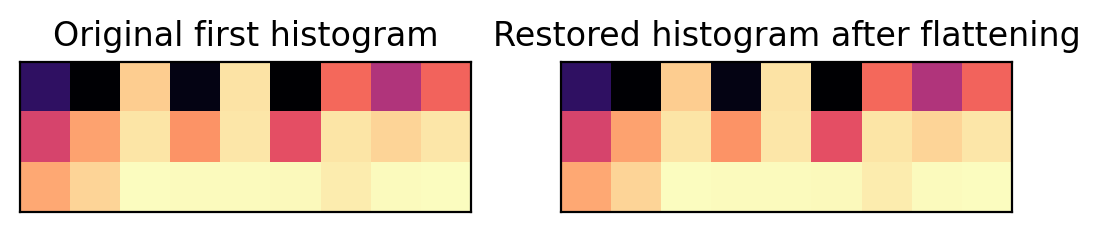

In [11]:
chromatin_gridder.create_deconvolution_matrices(plot=True)

In [47]:
from src.config import load_yl_replicate2_rg1_chromatin_config, \
    load_xg_gene_expression_config
from src.model import Model

gene_name = 'CLB2'

config = load_yl_replicate2_rg1_chromatin_config()
model = Model(config, gene_name, 0.1)
print("The shape of the convolution kernel matrix, H is: ", model.H.shape)

Initial branch: Recovery shape:  (15, 49)
Initial branch: postG1 shape:  (15, 79)
The shape of the convolution kernel matrix, H is:  (15, 226)


In [48]:
from src.deconvolve_chromatin import plot_deconvolved_chromatin
from src.deconvolve_chromatin import deconvolve_chromatin
from src.timer import Timer

timer = Timer()
result, f = deconvolve_chromatin(model, chromatin_gridder.deconv_hist)
print(f"Completed in {timer.get_time()}")
print(f"  The result was {result:.2f} and an F matrix of size {f.shape}")

Completed in 00:00:24.13
  The result was 8.24 and an F matrix of size (226, 27)


In [49]:
model.rn, model.sn

(34.20452004360851, 19.75484502327561)

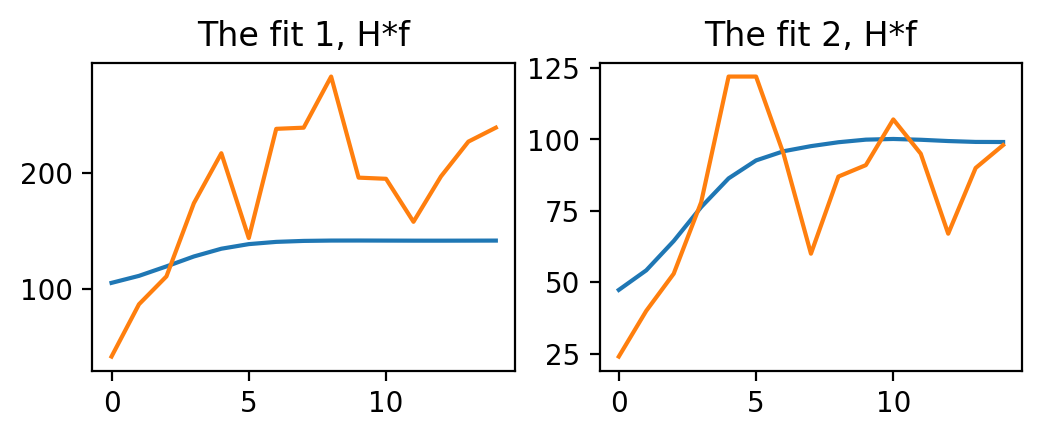

In [50]:
plot_deconvolved_chromatin(model.H, f, chromatin_gridder.deconv_hist)

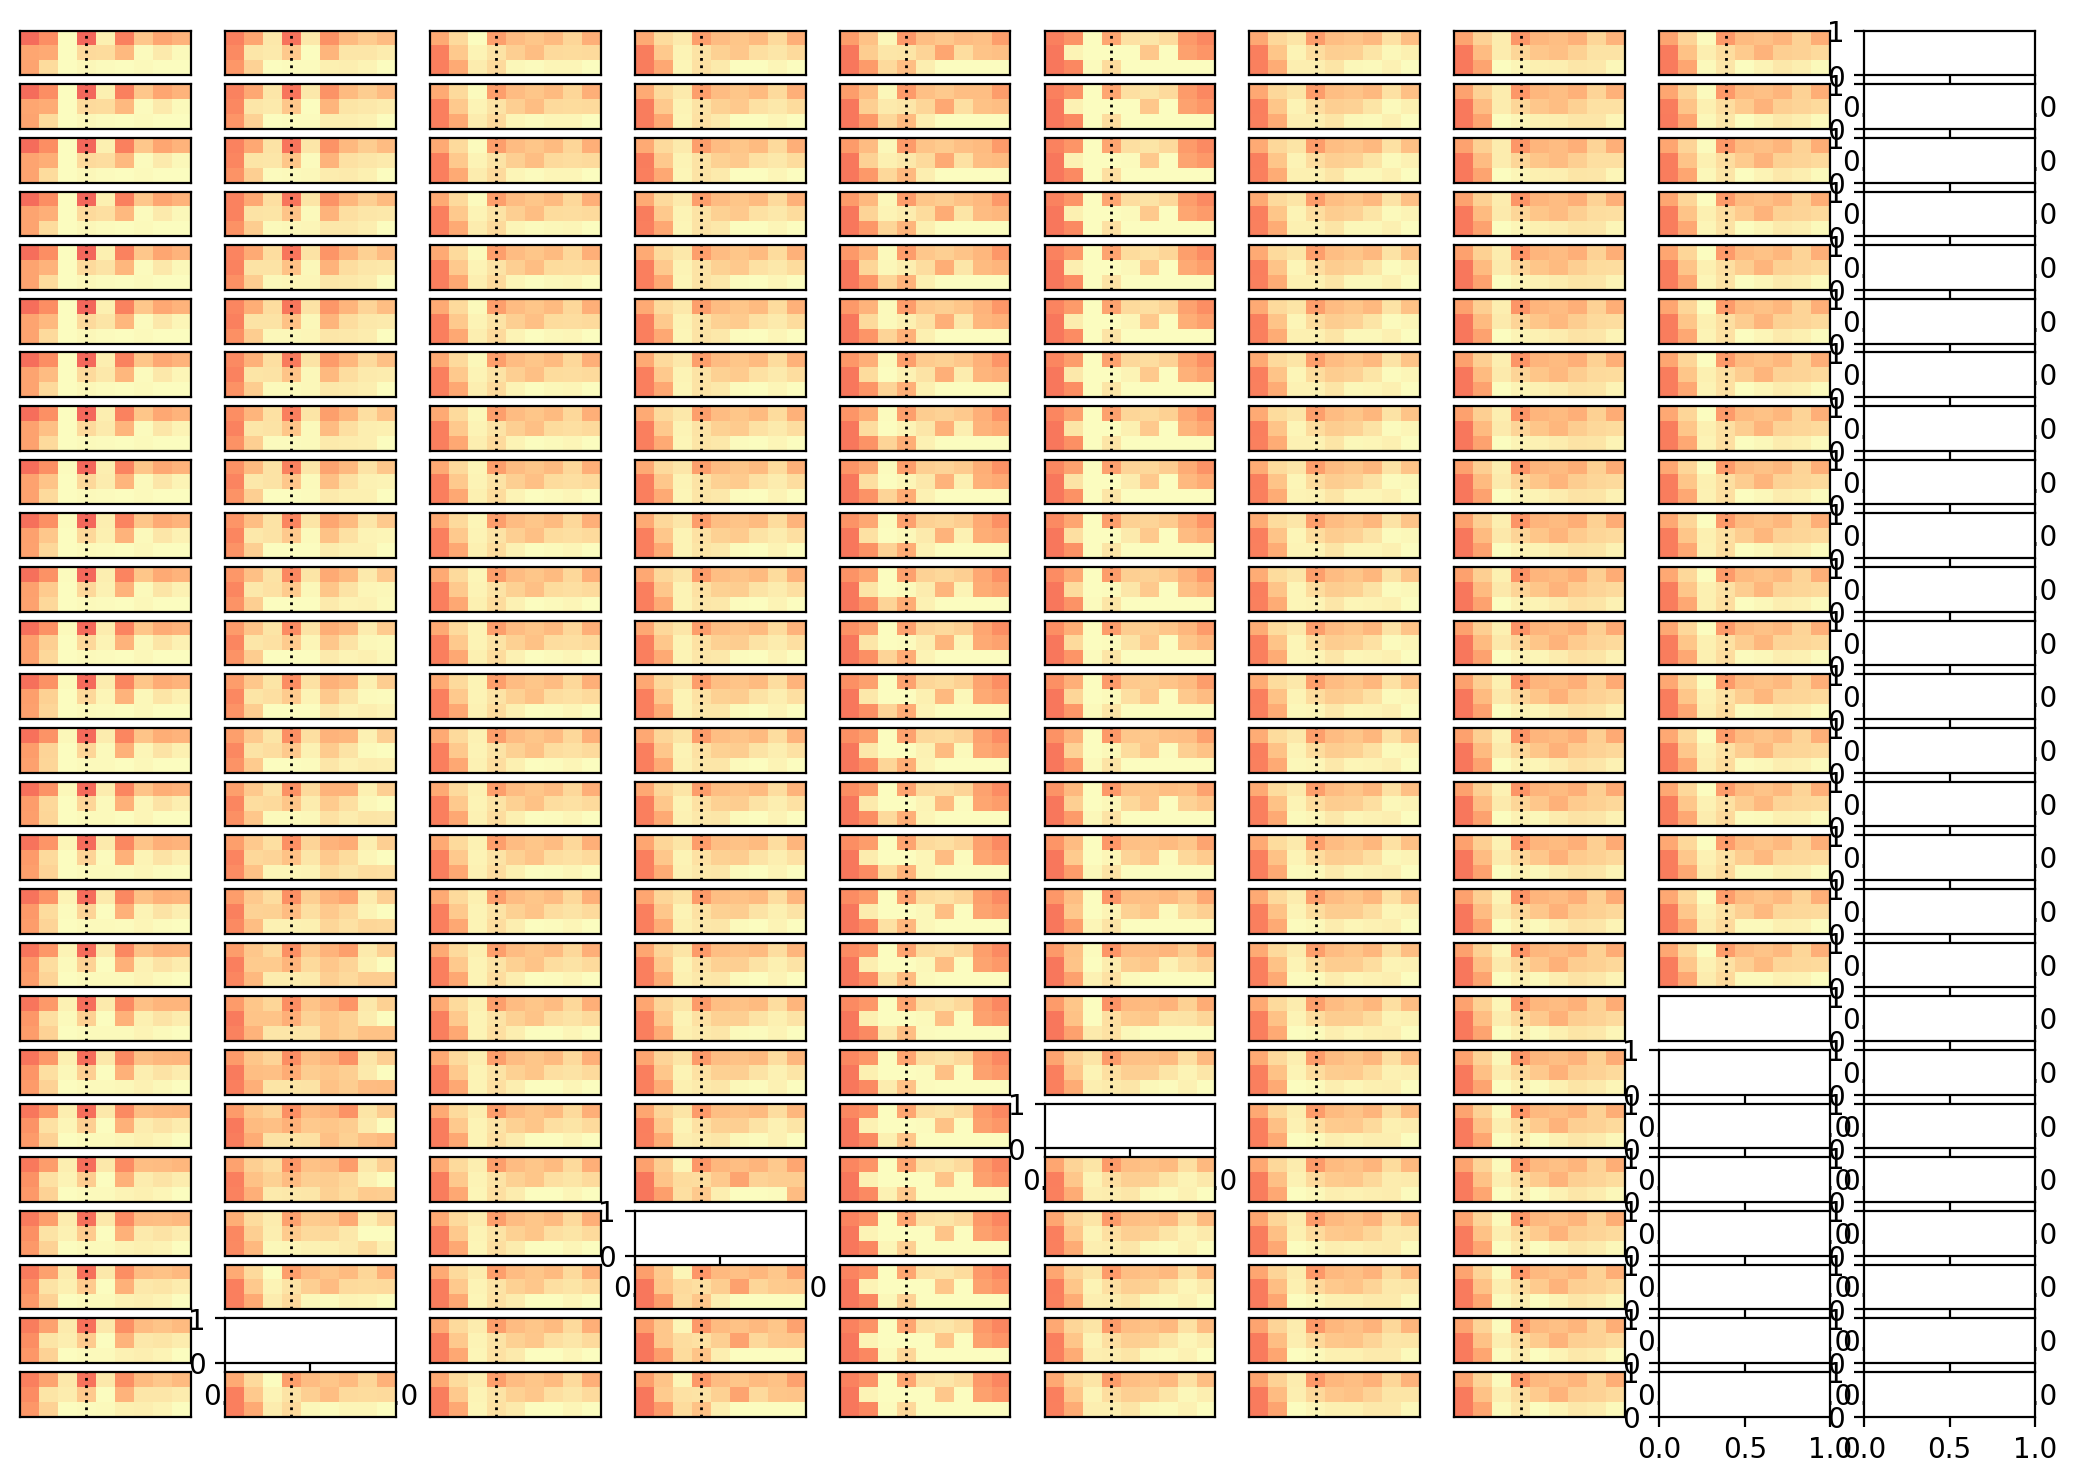

In [51]:
chromatin_gridder.create_deconvolution_plots(f, model)

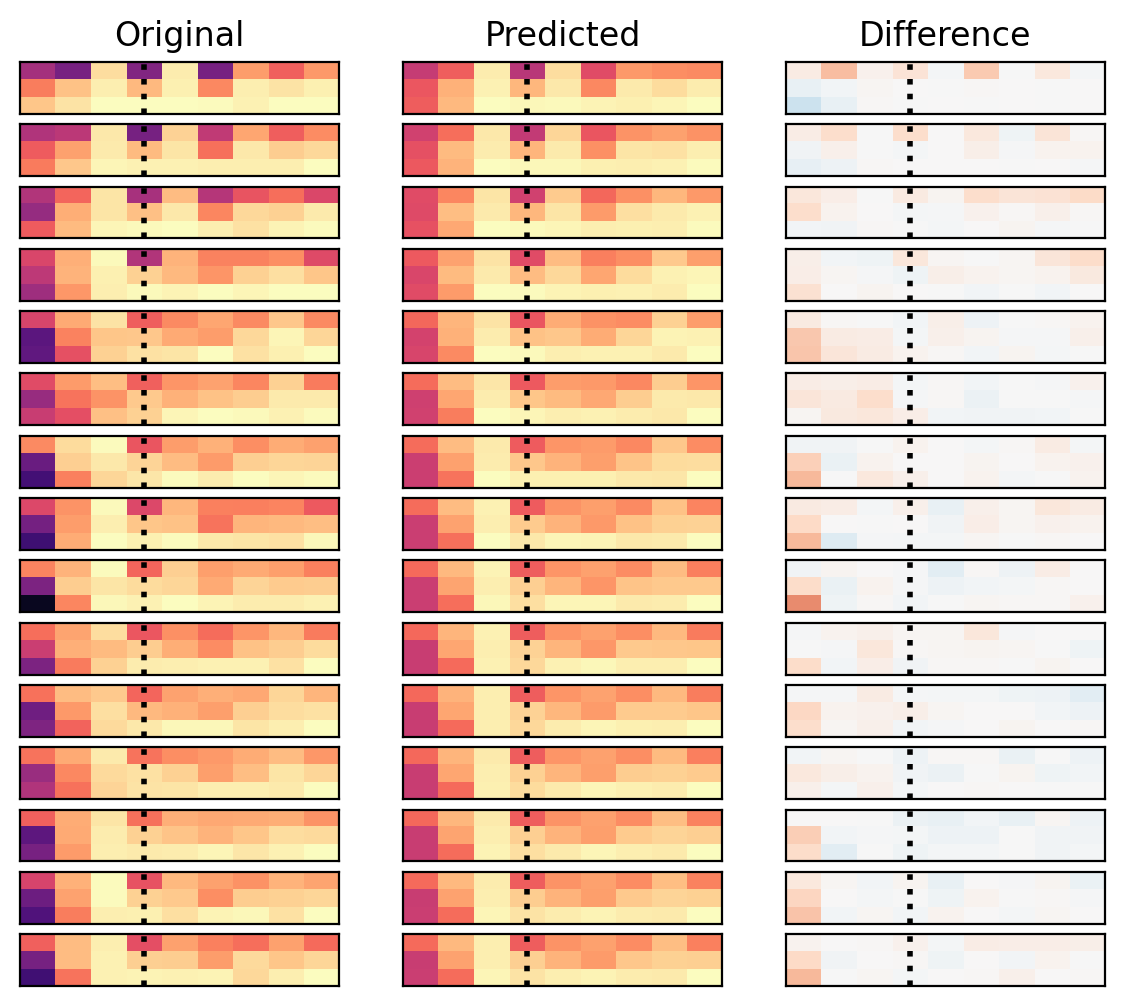

In [53]:
chromatin_gridder.plot_prediction_comparison(model, f)

In [54]:
from src.find_gamma_chromatin import FindOptimalGammaChromatin

find_gamma_chromatin = FindOptimalGammaChromatin(model, chromatin_gridder)

In [55]:
from src.timer import Timer

timer = Timer()

timer.start()
find_gamma_chromatin.find_optimal()

print(f"Finished finding the optimal gamma in : {timer.get_time()}")


findOptimal
  ... base_rn = 26.1780
  ... gamma in [0.0010, 0.1000]
  ...  search left, rn_goal = 26.2580, rate = 0.3
  ...  search right, rn_goal = 36.6492, rate = 40.0
  ... rn range: [26.3711, 34.2045]
  ... search gamma in [0.0010 0.1000] for elbow
  ...   gamma = 0.001, rn = 26.37, sn = 115.6
  ...   gamma = 0.0109, rn = 29.19, sn = 52
  ...   gamma = 0.0208, rn = 29.64, sn = 41.8
  ...   gamma = 0.0307, rn = 30.19, sn = 36.54
  ...   gamma = 0.0406, rn = 31.06, sn = 30.25
  ...   gamma = 0.0505, rn = 31.85, sn = 26.8
  ...   gamma = 0.0604, rn = 32.52, sn = 23.78
  ...   gamma = 0.0703, rn = 32.87, sn = 22.49
  ...   gamma = 0.0802, rn = 33.34, sn = 21.42
  ...   gamma = 0.0901, rn = 33.8, sn = 20.6
  ...   gamma = 0.1, rn = 34.2, sn = 19.75
The x_grad1 is: [2.82196063 1.63403547 0.49644454 0.70884503 0.83444832 0.73193581
 0.50890135 0.40925065 0.46578652 0.43263165 0.40027515]
The x_grad2 is: [-1.18792516 -1.16275804 -0.46259522  0.16900189  0.01154539 -0.16277349
 -0.16134258 

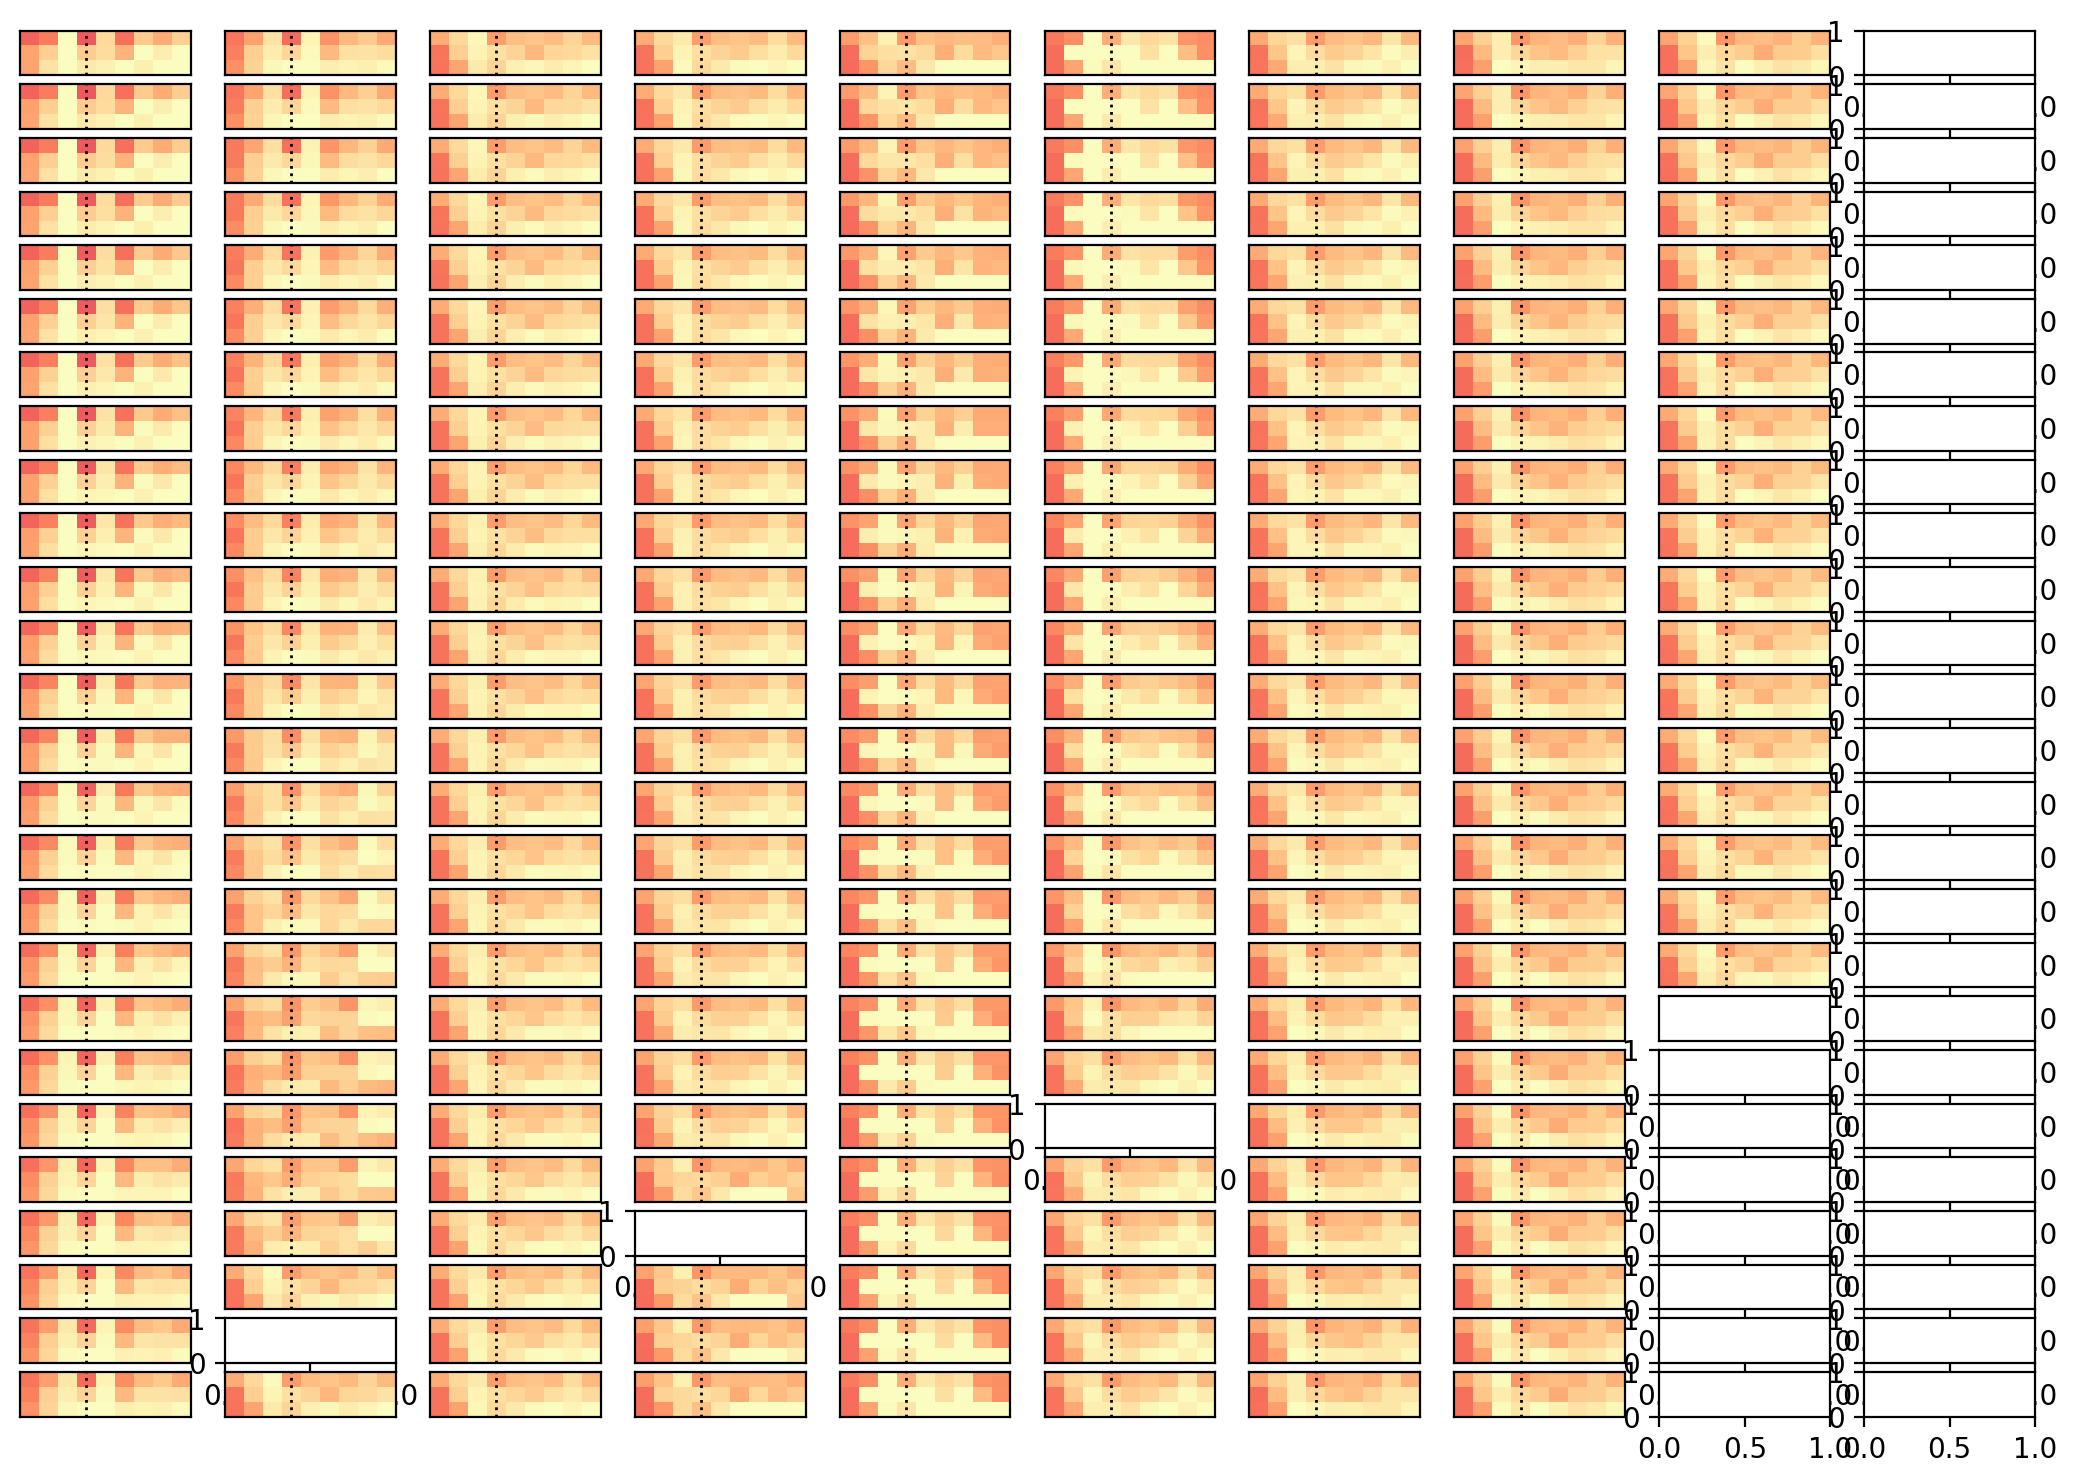

In [56]:
chromatin_gridder.create_deconvolution_plots(find_gamma_chromatin.f, model)

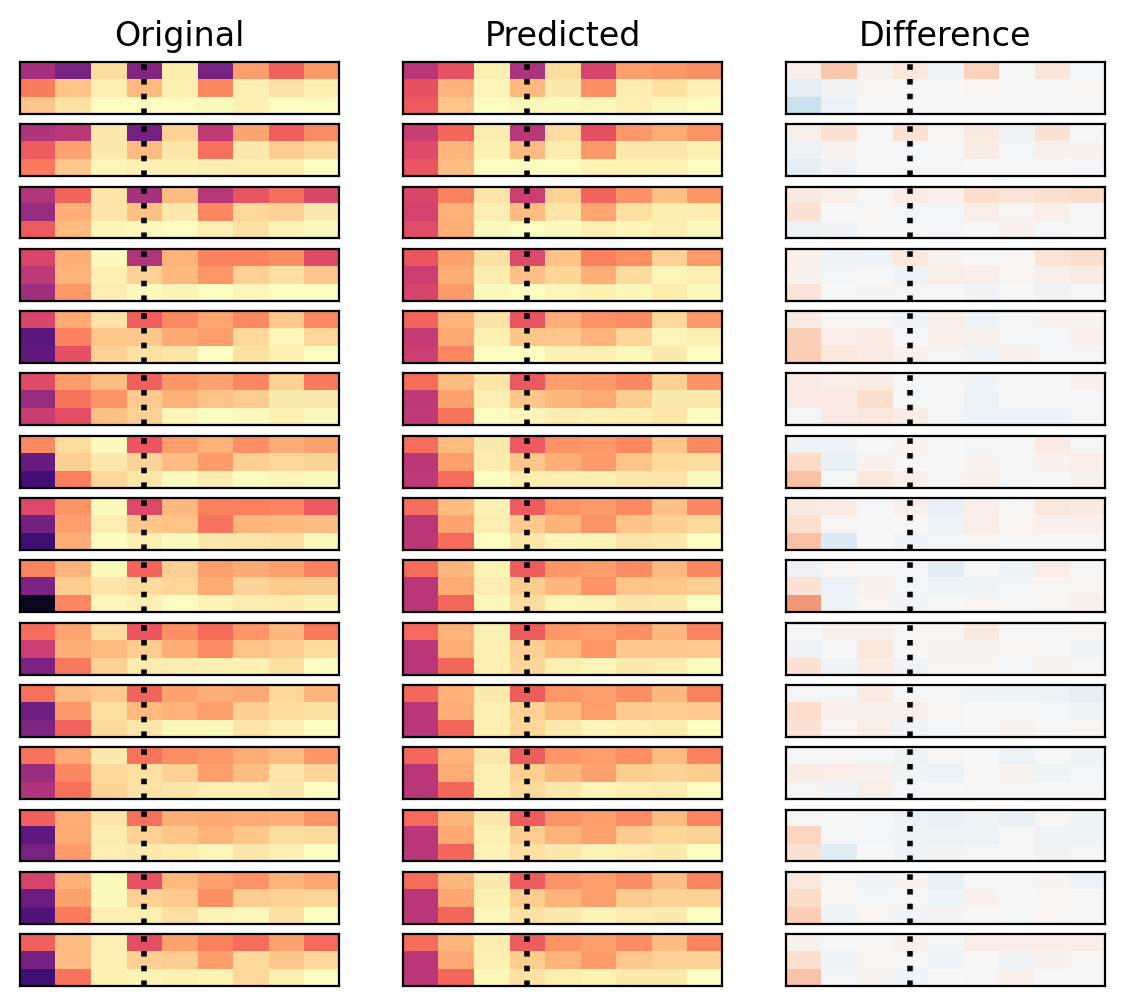

In [57]:
chromatin_gridder.plot_prediction_comparison(model, find_gamma_chromatin.f)

In [81]:
out_dir = 'output/deconvolve_chromatin_2023_12_12'